# Exploratory Data Analysis

In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\baw61\Downloads\job_postings_flat.csv')

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Filter for US Data Scientist roles

In [5]:
df_DS_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Scientist') & (df['job_location'] != 'United States')]

### Locations to Explore:

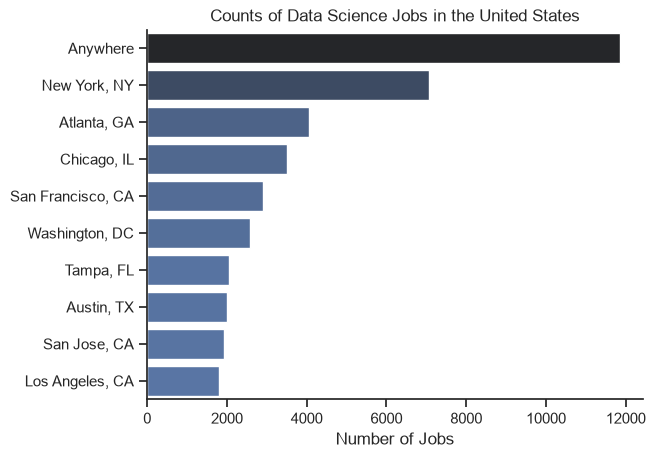

In [6]:
df_plot = df_DS_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Data Science Jobs in the United States')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Information for Job Postings

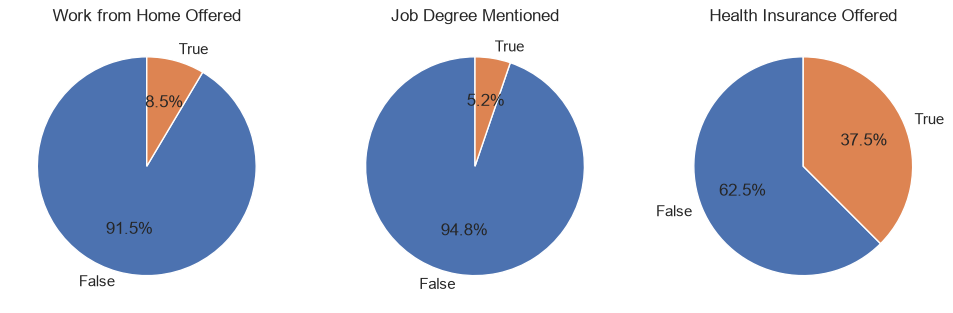

In [7]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12,5))

dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Job Degree Mentioned',
    'job_health_insurance': 'Health Insurance Offered'
}



for i, (column,title) in enumerate(dict_column.items()):
    ax[i].pie(df_DS_US[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)


plt.show()

### Companies to Explore:

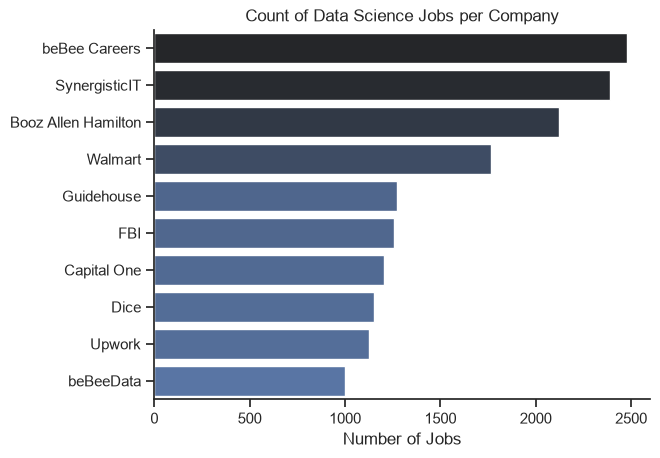

In [8]:
df_plot = df_DS_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Count of Data Science Jobs per Company')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()